# BLAES Units LFP Analyses

This notebook contains code for ...

---

> *Contact: Justin Campbell (justin.campbell@hsc.utah.edu)*  
> *Version: 05/14/2024*

## 1. Import Libraries

In [1]:
import os
import re
import mne
import sys
import glob
import datetime
import numpy as np
import numba as nb
import pandas as pd
from scipy.stats import wilcoxon, ranksums, norm
from scipy.signal import butter, hilbert, filtfilt
import mat73
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec
import seaborn as sns

# Import Blackrock Python Utilities
sys.path.append('/Users/justincampbell/Library/CloudStorage/GoogleDrive-u0815766@gcloud.utah.edu/My Drive/Research Projects/BLAESUnits/Code/Blacrock-Python-Utilities')
import brpylib

%matplotlib inline
# %config InlineBackend.figure_format='retina'
%config InlineBackend.figure_format='svg'

## 2. Set Paths & Parameters

In [2]:
# Params
fs = 30000
export = True

# Define paths
proj_path = '/Volumes/Hippocampus/BLAESUnits' # G-DRIVE Armor ATD External Drive
data_path = os.path.join(proj_path, 'Data_30k')
results_path = '/Users/justincampbell/Library/CloudStorage/GoogleDrive-u0815766@gcloud.utah.edu/My Drive/Research Projects/BLAESUnits/Results/'

# Get list of sessions
sessions = os.listdir(results_path)
sessions = [pID for pID in sessions if re.search(r'\d+$', pID)]

## 3. Load Data

In [3]:
def loadNSX(nsx_path):
    '''
    Load .nsx file and extract data and header.
    
    Arguments:
        nsx_path (str): path to .nsx file
        
    Returns:
        nsx_data (np.ndarray): raw neural data (30 kHz)
        header (dict): header (recording info)
    '''
    # Open .nsx file
    nsx_file = brpylib.NsxFile(nsx_path)

    # Extract data & header
    print('\nLoading .nsx data...')
    nsx_data = nsx_file.getdata(full_timestamps = True)['data'][0]
    header = nsx_file.extended_headers

    # Close .nev file
    nsx_file.close()
    
    return nsx_data, header

In [18]:
# Load sample session
session = 'UIC20230701'
fType = session[0:3]
save_path = os.path.join(results_path, session)

# Load LFP data
if fType == 'UIC':
    data, header = loadNSX(os.path.join(data_path, session, session + '.ns6'))
    chan_idxs = [header[i]['ElectrodeID'] for i in range(len(header))]
    chan_labels = [header[i]['ElectrodeLabel'] for i in range(len(header))]
    micro_labels = [x for x in chan_labels if x.startswith('m')]
    micro_idxs = [chan_labels.index(x) for x in micro_labels]

# Load events
events = pd.read_csv(os.path.join(results_path, session, 'Events.csv'), index_col = 0)
events['Chan-Unit'] = events['Channel'].astype(str) + '-' + events['Unit'].astype(str)

# Load stim epochs
stim_epochs = pd.read_csv(os.path.join(results_path, session, 'StimEpochs.csv'), index_col = 0)

# Load waveforms
wfs = pd.read_csv(os.path.join(results_path, session, 'Waveforms.csv'), index_col = 0)

# Load stats DF
stats_df = pd.read_csv(os.path.join(results_path, 'Group', 'SpikeStats.csv'), index_col = 0)
stats_df = stats_df[(stats_df['Condition'] == 'Stim') & (stats_df['Valid'] == True)].reset_index()


UIC20230701.ns6 opened

Loading .nsx data...

UIC20230701.ns6 closed


## 4. Create Epochs for STA

In [19]:
def circular_hist(ax, x, bins=16, density=True, offset=0, gaps=True):

    # Wrap angles to [-pi, pi)
    x = (x+np.pi) % (2*np.pi) - np.pi

    # Force bins to partition entire circle
    if not gaps:
        bins = np.linspace(-np.pi, np.pi, num=bins+1)

    # Bin data and record counts
    n, bins = np.histogram(x, bins=bins)

    # Compute width of each bin
    widths = np.diff(bins)

    # By default plot frequency proportional to area
    if density:
        # Area to assign each bin
        area = n / x.size
        # Calculate corresponding bin radius
        radius = (area/np.pi) ** .5
    # Otherwise plot frequency proportional to radius
    else:
        radius = n

    # Plot data on ax
    patches = ax.bar(bins[:-1], radius, zorder=5, align='edge', width=widths,
                    edgecolor = 'k', facecolor = color, fill=True, alpha = 0.75, linewidth=1)

    # Set the direction of the zero angle
    ax.set_theta_offset(offset)

    # Remove ylabels for area plots (they are mostly obstructive)
    if density:
        ax.set_yticks([])

    return n, bins, patches

In [20]:
def getSTAEpochs(unit):
    
    unit_idx = micro_labels.index(unit[:-2])
    unit_events = events[events['Chan-Unit'] == unit]

    # Remove events that are within 1 second of the start or end of the recording
    unit_events = unit_events[unit_events['TimeStamps'] > (1 * fs)]
    unit_events = unit_events[unit_events['TimeStamps'] < (len(data[unit_idx]) - (1 * fs))]

    # Filter waveforms by unit
    unit_events_idxs = unit_events.index
    unit_events = unit_events.reset_index(drop = True)
    unit_wfs = wfs.iloc[unit_events_idxs,:].reset_index(drop = True)

    # Get number of trials
    n_trials = stim_epochs.shape[1]
        
    # Get events in pre, during, and post-stim epochs
    pre_events = []
    during_events = []
    post_events = []
    for trial in range(n_trials):
        epoch_start = stim_epochs.iloc[:,trial].min()
        stim_start = epoch_start + (fs)
        epoch_end = stim_epochs.iloc[:,trial].max()
        stim_end = epoch_end - (fs)
        
        # get events for this trial
        trial_events = unit_events[(unit_events['TimeStamps'] > epoch_start) & (unit_events['TimeStamps'] < epoch_end)].copy()
        
        for spike in trial_events['TimeStamps']:
            if spike < stim_start:
                pre_events.append(spike)
            elif spike > stim_end:
                post_events.append(spike)
            else:
                during_events.append(spike)
                
    # Get spike times for each epoch and trial
    epochs_pre = np.zeros((len(pre_events), fs * 2))
    epochs_during = np.zeros((len(during_events), fs * 2))
    epochs_post = np.zeros((len(post_events), fs * 2))
    pad = 1 * fs # 1 s

    for event in range(len(pre_events)):
        spike_onset = pre_events[event]
        epoch = data[unit_idx, np.arange((spike_onset - pad), (spike_onset + pad), 1).astype(int)]
        epochs_pre[event] = epoch
        
    for event in range(len(during_events)):
        spike_onset = during_events[event]
        epoch = data[unit_idx, np.arange((spike_onset - pad), (spike_onset + pad), 1).astype(int)]
        epochs_during[event] = epoch
        
    for event in range(len(post_events)):
        spike_onset = post_events[event]
        epoch = data[unit_idx, np.arange((spike_onset - pad), (spike_onset + pad), 1).astype(int)]
        epochs_post[event] = epoch
        
    return epochs_pre, epochs_during, epochs_post, unit_wfs

In [25]:
def plotThetaSTA(unit, unit_waveforms, epochs, color = 'k', show = True, save_str = None):
    '''
    Plot...
    
    Arguments:
        - X
        
    Returns:
        None
    '''
    
    ### ORGANIZE DATA ###
    if epochs.shape[0] == 0:
        return
        
    # Melt DataFrame for plotting in Seaborn
    unit_waveforms['Spike'] = np.arange(unit_waveforms.shape[0])
    unit_waveforms = unit_waveforms.melt(id_vars = ['Spike'], var_name = 'Time', value_name = 'Voltage')
    
    # Adjust time (samples -> ms)
    unit_waveforms['Time'] = unit_waveforms['Time'].astype(int)
    unit_waveforms['Time'] = (unit_waveforms['Time'] / fs) * 1000 # convert to ms
    
    # Get average waveform
    if fType == 'UIC':
        wf_len = 47
    wf_mean = unit_waveforms.groupby('Time')['Voltage'].mean().values[:wf_len]
    wf_min_idx = np.argmin(wf_mean)
    
    # Subtract average waveform from epochs
    epochs[:, (30000 - wf_min_idx):(30000 - wf_min_idx + wf_len)] = epochs[:, (30000 - wf_min_idx):(30000 - wf_min_idx + wf_len)] - wf_mean
    
    # Downsample micro LFP from 30 kHz to 2 kHz
    epochs = epochs[:, ::15]
    
    # Bandpass filter unit_sta in 3-10 Hz range
    nyq = 0.5 * 2000
    low = 3 / nyq
    high = 10 / nyq
    b, a = butter(4, [low, high], btype='band')
    sta_theta = filtfilt(b, a, epochs)
    sta_theta_mean = sta_theta.mean(axis = 0)
    
    # Compute theta phase
    theta_phases = np.angle(hilbert(sta_theta))
    theta_phases = theta_phases[:, 2000]
    
    ### PLOTTING ###
    # Figure parameters
    fig = plt.figure(figsize=(8, 2))
    gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, .8])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2], polar=True)
    gs.update(wspace=0.5)  # General spacing between all subplots

    # Plot average waveform ± SD (shaded)
    sns.lineplot(x = 'Time', y = 'Voltage', data = unit_waveforms, color = color, linewidth = 3, errorbar = 'sd', ax = ax1)
    
    # Plot theta-filtered trace
    ax2.plot(np.arange(-2000, 2000, 1), sta_theta_mean, color = color, linewidth = 3, zorder = 1)
    ax2.axvline(x = 0, color = 'k', linestyle = '--', linewidth = 1, zorder = 2)
    
    # Plot polar histogram of theta phases
    circular_hist(ax = ax3, x = theta_phases)
    # ax3.plot([0, theta_phases.mean()], [0, .2], color = 'k', linewidth = 2, zorder = 6)
    
    # Figure aeshetics
    if fType == 'UIC':
        ax1.set_xlim([0, 1.5])
        ax1.set_xticks([0, 0.5, 1, 1.5])
    elif fType == 'BJH':
        ax1.set_xlim([0, 1])
        ax1.set_xticks([0, 0.5, 1])
    ax1.set_xlabel('Time (ms)', fontsize = 'large')
    ax1.set_yticks([np.floor(wf_mean.min())-20, 0, np.ceil(wf_mean.max())+20])
    ax1.set_ylim([np.floor(wf_mean.min())-20, np.ceil(wf_mean.max())+20])
    ax1.set_ylabel('Voltage ($\mu$V)', fontsize = 'large')
    ax2.set_xlim([-500, 500])
    ax2.set_yticks([np.floor(sta_theta_mean.min())-1, 0, np.ceil(sta_theta_mean.max())+1])
    ax2.set_ylim([np.floor(sta_theta_mean.min())-1, np.ceil(sta_theta_mean.max())+1])
    ax2.set_xlabel('Time (ms)', fontsize = 'large')
    ax2.set_ylabel('Voltage ($\mu$V)', fontsize = 'large')
    ax3.set_xticks(np.linspace(0, 2*np.pi, 4, endpoint=False))
    for ax in [ax1, ax2]:
        sns.despine(top = True, right = True, ax = ax)
    plt.suptitle(unit, y = 1.1, fontsize = 'x-large', fontweight = 'bold')
    
    # Export figure
    if save_str is not None:
        if not os.path.exists(os.path.join(save_path, 'LFP')):
            os.mkdir(os.path.join(save_path, 'LFP'))
        plt.savefig(os.path.join(save_path, 'LFP', save_str + '.pdf'), dpi = 1500, bbox_inches = 'tight')
    
    if show == False:
        plt.close()

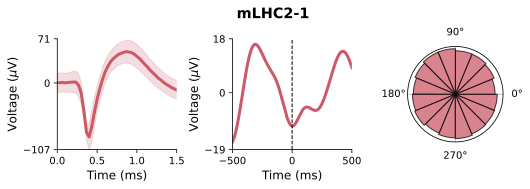

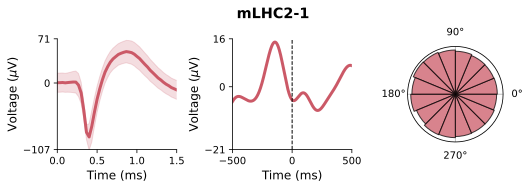

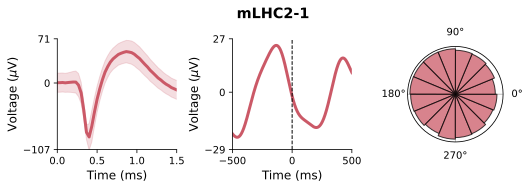

In [26]:
# Plot Theta STA for all valid, modulated units
for unit in events['Chan-Unit'].unique():
    unit_stats = stats_df[(stats_df['pID'] == session) & (stats_df['Unit'] == unit) & (stats_df['Sig'] == True)]
    if unit_stats.shape[0] == 0:
        continue

    # Assign region label
    regionDict = {'CV': 'ACC', 'HIP': 'HIP', 'ACC': 'ACC', 'CD': 'ACC', 'OFC': 'OFC',
                'VCG': 'ACC', 'AHIP': 'HIP', 'HC': 'HIP', 'HCA': 'HIP', 'DAC': 'ACC', 
                'DCG': 'ACC', 'AMY': 'AMY', 'FUG': 'FUG'}
    if unit[2:5] in regionDict.keys():
        region = regionDict[unit[2:5]]
        
    # Set color (by region)
    palette = sns.color_palette('flare', 4, desat = 0.85)
    if region == 'HIP':
        color = palette[0]
    elif region == 'OFC':
        color = palette[1]
    elif region == 'AMY':
        color = palette[2]
    elif region == 'ACC':
        color = palette[3]
        
    # Get spike-triggered theta epochs
    [epochs_pre, epochs_during, epochs_post, unit_wfs] = getSTAEpochs(unit)
        
    # Plot
    plotThetaSTA(unit, unit_wfs, epochs_pre, color = color, save_str = unit + '_ThetaSTA_Pre')
    plotThetaSTA(unit, unit_wfs, epochs_during, color = color, save_str = unit + '_ThetaSTA_During')
    plotThetaSTA(unit, unit_wfs, epochs_post, color = color, save_str = unit + '_ThetaSTA_Post')